In [ ]:
!pip install kagglehub tensorflow numpy opencv-python matplotlib seaborn scikit-learn

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from kagglehub import dataset_download
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import itertools
from google.colab import drive
from tensorflow.keras.preprocessing.image import img_to_array

In [ ]:
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Download dataset from KaggleHub
dataset_path = dataset_download('mohamedmustafa/real-life-violence-situations-dataset')
data_dir = os.path.join(dataset_path, 'Real Life Violence Dataset')

100%|██████████| 3.58G/3.58G [01:35<00:00, 40.1MB/s]

Extracting files...


In [ ]:
# # Function to extract frames from videos
# def extract_frames(video_path, frame_count=10):
#     cap = cv2.VideoCapture(video_path)
#     frames = []
#     total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#     for i in np.linspace(0, total_frames - 1, frame_count).astype(int):
#         cap.set(cv2.CAP_PROP_POS_FRAMES, i)
#         ret, frame = cap.read()
#         if ret:
#             frame = cv2.resize(frame, (224, 224))
#             frame = img_to_array(frame) / 255.0
#             frames.append(frame)
#     cap.release()
#     return np.array(frames)

In [ ]:
# # Load dataset
# def load_videos_from_directory(directory, frame_count=10):
#     X, y = [], []
#     class_names = os.listdir(directory)
#     class_map = {name: i for i, name in enumerate(class_names)}
#     for class_name in class_names:
#         class_path = os.path.join(directory, class_name)
#         for video in os.listdir(class_path):
#             video_path = os.path.join(class_path, video)
#             frames = extract_frames(video_path, frame_count)
#             if frames.shape[0] == frame_count:
#                 X.append(frames)
#                 y.append(class_map[class_name])
#     return np.array(X), np.array(y), class_names

In [ ]:
def extract_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return None  # Handle broken videos

    middle_frame_idx = total_frames // 2  # Get middle frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame_idx)

    ret, frame = cap.read()
    cap.release()

    if ret:
        frame = cv2.resize(frame, (224, 224))
        frame = img_to_array(frame) / 255.0
        return frame
    else:
        return None


In [ ]:
def load_videos_from_directory(directory):
    X, y = [], []
    class_names = os.listdir(directory)
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        for video in os.listdir(class_path):
            video_path = os.path.join(class_path, video)
            frame = extract_frame(video_path)  # Extract a single frame

            if frame is not None:
                X.append(frame)
                y.append(class_map[class_name])

    X = np.array(X)
    y = np.array(y)

    # **Fix: Remove any extra dimensions**
    X = np.squeeze(X)

    print(f"Dataset loaded: {X.shape}, Labels: {y.shape}")  # Debugging print

    return X, y, class_names


In [ ]:
X, y, class_names = load_videos_from_directory(data_dir)
X = X.reshape(X.shape[0], -1, 224, 224, 3)  # Reshape to match input format

Dataset loaded: (2000, 224, 224, 3), Labels: (2000,)


In [ ]:
# Split dataset
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (1600, 1, 224, 224, 3)
y_train shape: (1600,)


In [ ]:
X_train = np.squeeze(X_train, axis=1)
X_val = np.squeeze(X_val, axis=1)

print("Fixed X_train shape:", X_train.shape)  # Should be (1600, 224, 224, 3)
print("Fixed X_val shape:", X_val.shape)


Fixed X_train shape: (1600, 224, 224, 3)
Fixed X_val shape: (400, 224, 224, 3)


In [ ]:
# Build Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
output_layer = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output_layer)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Save best model
checkpoint_filepath = '/content/drive/MyDrive/best_model.h5'
checkpoint = ModelCheckpoint(checkpoint_filepath, monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
epochs = 20
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=8, callbacks=[checkpoint, early_stopping])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

...

200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8893 - loss: 0.2821 - val_accuracy: 0.8675 - val_loss: 0.2541
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9005 - loss: 0.2464
Epoch 5: val_loss improved from 0.25409 to 0.24998, saving model to /content/drive/MyDrive/best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9005 - loss: 0.2464 - val_accuracy: 0.8800 - val_loss: 0.2500
Epoch 6/20
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9154 - loss: 0.2140
Epoch 6: val_loss improved from 0.24998 to 0.23364, saving model to /content/drive/MyDrive/best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9153 - loss: 0.2141 - val_accuracy: 0.8925 - val_loss: 0.2336
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9012 - loss: 0.2413
Epoch 7: val_loss improved from 0.23364 to 0.23027, saving model to /content/drive/MyDrive/best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9012 - loss: 0.2413 - val_accuracy: 0.8875 - val_loss: 0.2303
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9103 - loss: 0.2290
Epoch 8: val_loss improved from 0.23027 to 0.22267, saving model to /content/drive/MyDrive/best_model.h5


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9103 - loss: 0.2290 - val_accuracy: 0.8950 - val_loss: 0.2227
Epoch 9/20
196/200 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9203 - loss: 0.2042
Epoch 9: val_loss did not improve from 0.22267
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9202 - loss: 0.2046 - val_accuracy: 0.8950 - val_loss: 0.2300
Epoch 10/20
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9026 - loss: 0.2383
Epoch 10: val_loss did not improve from 0.22267
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9026 - loss: 0.2383 - val_accuracy: 0.8900 - val_loss: 0.2302
Epoch 11/20
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9180 - loss: 0.2053
Epoch 11: val_loss did not improve from 0.22267
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9179 - loss: 0.2055 - val_accuracy: 0.8950 - val_loss: 0.2278
Epoch 12/20
197/200 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8974 - loss: 0.2347
Epoch 12: val_loss did not improve

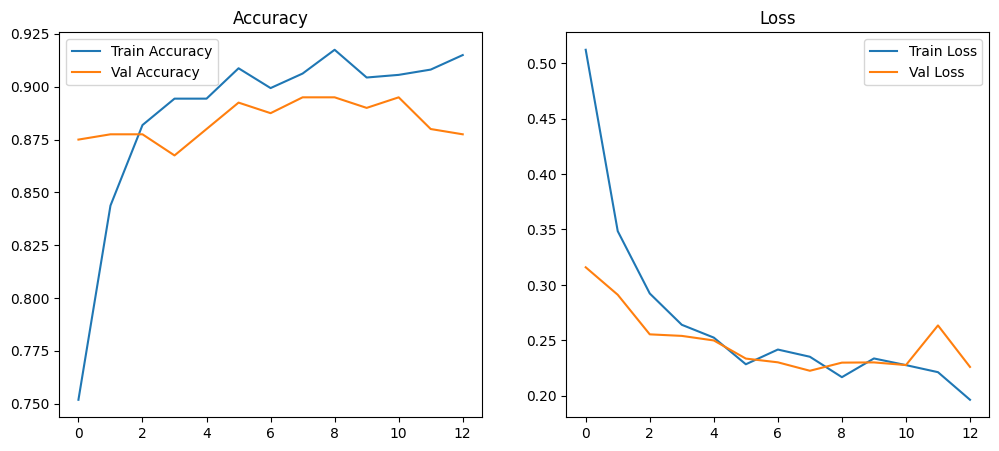

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 475ms/step

Classification Report:
              precision    recall  f1-score   support

 NonViolence       0.90      0.89      0.89       199
    Violence       0.89      0.90      0.90       201

    accuracy                           0.90       400
   macro avg       0.90      0.89      0.89       400
weighted avg       0.90      0.90      0.89       400



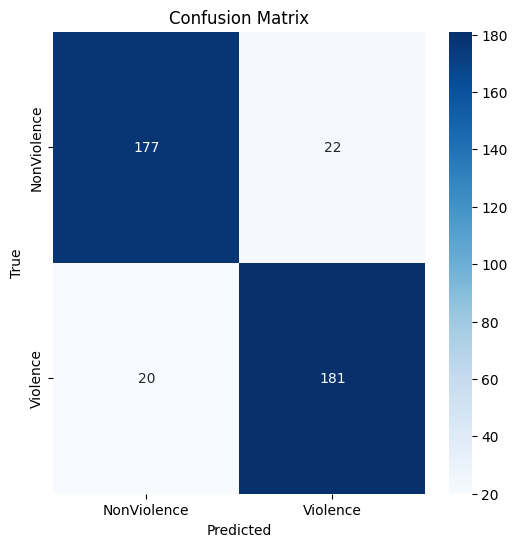

Best model saved at: /content/drive/MyDrive/best_model.h5


In [ ]:
# Plot training history
def plot_metrics(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()

plot_metrics(history)

# Evaluate on validation set
y_pred = (model.predict(X_val) > 0.5).astype("int32")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(y_val, y_pred, class_names)

print("Best model saved at:", checkpoint_filepath)


In [3]:
import tensorflow as tf
import numpy as np
import cv2
import os
from tensorflow.keras.models import load_model
from google.colab import drive

drive.mount('/content/drive')

# Load the best model saved during training
model_path = "/content/drive/MyDrive/best_model.h5"  # Change this to your model path
model = load_model(model_path)

# Function to extract frames from a video
def extract_frames(video_path, frame_interval=10):
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % frame_interval == 0:  # Take every 'frame_interval' frame
            frame = cv2.resize(frame, (224, 224))  # Resize to match model input
            frame = frame / 255.0  # Normalize pixel values
            frames.append(frame)

        frame_count += 1

    cap.release()
    frames = np.array(frames)  # Convert list to numpy array
    return frames




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Function to predict video class
def predict_video(video_path):
    frames = extract_frames(video_path)

    if frames.shape[0] == 0:
        print("No frames extracted. Check the video file.")
        return None

    predictions = model.predict(frames)  # Predict each frame
    avg_prediction = np.mean(predictions, axis=0)  # Average frame predictions
    predicted_class = np.argmax(avg_prediction)  # Get the final class

    class_labels = ["Non-Violence", "Violence"]  # Update based on your dataset labels
    return class_labels[predicted_class], avg_prediction

In [13]:
import IPython.display as display
from google.colab import files

# Function to display video in an iframe
def display_video(video_path):
    print(f"Displaying video: {video_path}")
    return display.HTML(f"""
        <video width="600" height="400" controls>
            <source src="{video_path}" type="video/mp4">
            Your browser does not support the video tag.
        </video>
    """)






In [15]:
video_path = "/test1.mp4"  # Change to your test video path
# Predict the video class
predicted_class, confidence = predict_video(video_path)

# Print prediction results
if predicted_class is not None:
    print(f"Predicted Class: {predicted_class} with Confidence: {float(confidence[0]):.2f}")

else:
    print("Failed to predict class for the given video.")

# Display the video in an iframe
display_video(video_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Class: Non-Violence with Confidence: 0.14
Displaying video: /test1.mp4


In [17]:
video_path = "/test2.mp4"  # Change to your test video path
# Predict the video class
predicted_class, confidence = predict_video(video_path)

# Print prediction results
if predicted_class is not None:
    print(f"Predicted Class: {predicted_class} with Confidence: {float(confidence[0]):.2f}")
else:
    print("Failed to predict class for the given video.")

# Display the video in an iframe
display_video(video_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Class: Non-Violence with Confidence: 0.37
Displaying video: /test2.mp4


In [18]:
video_path = "/test3.mp4"  # Change to your test video path
# Predict the video class
predicted_class, confidence = predict_video(video_path)

# Print prediction results
if predicted_class is not None:
    print(f"Predicted Class: {predicted_class} with Confidence: {float(confidence[0]):.2f}")
else:
    print("Failed to predict class for the given video.")

# Display the video in an iframe
display_video(video_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Class: Non-Violence with Confidence: 0.39
Displaying video: /test3.mp4
